In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
130,2025-26,1631172,Ousmane Dieng,Ousmane,1610612749,MIL,Milwaukee Bucks,22501126,2026-04-03T00:00:00,MIL vs. BOS,L,23.983333,4,15,0.267,1,4,0.250,0,0,0.0,0,3,3,1,1,0,0,1,2,0,9,-32,13.1,0,0,14.0,1,23:59,1,94.0,97.9,97.9,155.5,159.2,159.2,-61.5,-61.3,-61.3,0.091,1.0,5.9,0.000,0.158,0.060,5.9,5.9,0.300,0.300,0.296,0.297,99.19,96.07,80.06,96.07,-0.009,47,4.0,15.0,35,83,0.422,21,47,0.447,10,13,0.769,8,22,30,24,13.0,5,4,4,21,13,101,-32.0,107.8,109.8,138.0,141.5,-30.3,-31.7,0.686,1.85,19.0,0.200,0.600,0.378,0.141,0.548,0.569,95.0,93.0,77.50,92,0.322,1610612738,BOS,Boston Celtics,50,89,0.562,17,37,0.459,16,19,0.842,10,38,48,33,9.0,7,4,4,13,21,133,32.0,138.0,141.5,107.8,109.8,30.3,31.7,0.660,3.67,23.1,0.400,0.800,0.622,0.096,0.657,0.683,95.0,93.0,77.50,94,0.678,G,C,22.0,1
129,2025-26,1629013,Landry Shamet,Landry,1610612752,NYK,New York Knicks,22501123,2026-04-03T00:00:00,NYK vs. CHI,W,12.683333,3,7,0.429,2,4,0.500,0,0,0.0,1,0,1,1,0,1,0,0,0,0,8,12,13.7,0,0,14.0,1,12:41,1,143.6,137.0,137.0,95.9,92.6,92.6,47.8,44.4,44.4,0.083,0.0,12.5,0.083,0.000,0.037,0.0,0.0,0.571,0.571,0.233,0.243,98.09,102.18,85.15,102.18,0.105,27,3.0,7.0,48,91,0.527,15,39,0.385,25,28,0.893,13,41,54,30,9.0,11,3,2,21,23,136,40.0,136.9,136.0,96.5,96.0,40.4,40.0,0.625,3.33,20.7,0.333,0.788,0.577,0.090,0.610,0.658,99.4,100.0,83.33,100,0.713,1610612741,CHI,Chicago Bulls,35,81,0.432,11,35,0.314,15,26,0.577,9,27,36,24,16.0,4,2,3,23,21,96,-40.0,96.5,96.0,136.9,136.0,-40.4,-40.0,0.686,1.50,17.8,0.212,0.667,0.423,0.160,0.500,0.519,99.4,100.0,83.33,100,0.287,NaN,SG,28.0,0
128,2025-26,1630182,Josh Green,Josh,1610612766,CHA,Charlotte Hornets,22501120,2026-04-03T00:00:00,CHA vs. IND,W,24.400000,2,5,0.400,2,4,0.500,0,0,0.0,1,1,2,2,0,1,0,0,2,0,6,8,14.4,0,0,14.0,1,24:24,1,124.2,125.5,125.5,109.4,107.7,107.7,14.8,17.8,17.8,0.100,0.0,28.6,0.036,0.036,0.036,0.0,0.0,0.600,0.600,0.088,0.088,101.04,101.31,84.43,101.31,0.044,51,2.0,5.0,46,96,0.479,24,49,0.490,13,15,0.867,12,36,48,31,10.0,8,7,1,18,18,129,21.0,128.2,130.3,109.8,109.1,18.5,21.2,0.674,3.10,21.5,0.275,0.722,0.505,0.101,0.604,0.629,99.5,99.0,82.50,99,0.574,1610612754,IND,Indiana Pacers,43,93,0.462,15,36,0.417,7,10,0.700,11,34,45,29,12.0,5,1,7,18,18,108,-21.0,109.8,109.1,128.2,130.3,-18.5,-21.2,0.674,2.42,20.6,0.278,0.725,0.495,0.121,0.543,0.554,99.5,99.0,82.50,99,0.426,NaN,SG,25.0,0
139,2025-26,203937,Kyle Anderson,Kyle,1610612750,MIN,Minnesota T

In [3]:
def apply_bayesian_ppm(df, confidence_k=20, min_minutes=1.0):
    """
    Shrink player PTS/MIN toward a (pos, STARTING) role prior.
    confidence_k: pseudo sample size for the prior (same interpretation as minutes).
    min_minutes: only rows with MIN >= this contribute to PPM (avoids divide-by-zero).
    """
    df = df.copy()
    df["_ppm"] = np.where(df["MIN"] >= min_minutes, df["PTS"] / df["MIN"], np.nan)

    priors = df.groupby(["pos", "STARTING"], dropna=False)["_ppm"].mean().to_dict()

    player_stats = df.groupby("PLAYER_ID", as_index=False).agg(
        player_mean_ppm=("_ppm", "mean"),
        games_played=("_ppm", "count"),
    )

    df = df.merge(player_stats, on="PLAYER_ID", how="left")

    def _prior_for_row(row):
        key = (row["pos"], row["STARTING"])
        v = priors.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return float(df["_ppm"].mean())
        return float(v)

    df["prior_ppm"] = df.apply(_prior_for_row, axis=1)

    df["bayesian_ppm_proj"] = (
        (df["games_played"] * df["player_mean_ppm"]) + (confidence_k * df["prior_ppm"])
    ) / (df["games_played"] + confidence_k)

    df["bayesian_ppm_proj"] = df["bayesian_ppm_proj"].round(4)
    df = df.drop(columns=["_ppm"], errors="ignore")

    return df["bayesian_ppm_proj"]

In [4]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    # df['STARTING'] = df['START_POSITION'].notna().astype(int)
    df['BAYES_PPM_PROJ'] = apply_bayesian_ppm(df)
    df = ppm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['MEDIAN_PTS_PER_MIN_ROLLING_10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["PTS_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["PTS_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FGA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FGA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FGA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["3PA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["3PA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["3PA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["FTA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FTA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["FTA_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df["PTS_ewm3"] = df.groupby("PLAYER_ID")["PTS"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['PTS_ewm5'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['PTS_ewm10'] = (df.groupby('PLAYER_ID')['PTS'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_ewm3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(83106, 274)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,BAYES_PPM_PROJ,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,AST_roll3,TOV_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,AST_roll5,TOV_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,AST_roll10,TOV_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,NET_RATING_roll5,TEAM_PACE_roll5,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_PTS_PER_MIN_RANK_L5,TEAM_PTS_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,MEDIAN_PTS_PER_MIN_ROLLING_10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_10_ewm,3PA_PER_MIN_5_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_10_ewm,FTA_PER_MIN_5_ewm,FTA_PER_MIN_3_ewm,PTS_ewm3,PTS_ewm5,PTS_ewm10,MIN_ewm10,MIN_ewm5,MIN_ewm3,GP,BLOWOUT_RISK,START_POSITION
83101,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500967,2026-03-13,UTA @ POR,L,28.55,2,6,0.333,0,3,0.000,2,2,1.000,2,1,3,2,3,2,0,0,4,4,6,-11,15.6,0,0,15.0,1,28:33,1,86.3,88.7,88.7,106.0,103.1,103.1,-19.7,-14.4,-14.4,0.111,0.67,16.7,0.057,0.032,0.045,25.0,25.3,0.333,0.436,0.137,0.138,105.92,105.92,88.27,105.92,0.009,62,2.0,6.0,42,92,0.457,13,30,0.433,17,22,0.773,10,26,36,28,18.0,16,3,12,17,19,114,-10.0,103.9,107.5,116.9,115.9,-13.0,-8.3,0.667,1.56,18.8,0.294,0.636,0.453,0.170,0.527,0.561,107.9,106.5,88.75,106,0.427,1610612757,POR,Portland Trail Blazers,46,89,0.517,17,46,0.370,15,16,0.938,14,35,49,34,24.0,16,12,3,19,17,124,10.0,116.9,115.9,

In [5]:
PPM_FEATURES = [
    # EWM
    "PTS_ewm10",
    "PTS_ewm5",
    "MIN_ewm10",
    "MIN_ewm5",

    # PTS per Min EWM
    "BAYES_PPM_PROJ",
    "PTS_PER_MIN_10_ewm",
    "PTS_PER_MIN_5_ewm",
    'MEDIAN_PTS_PER_MIN_ROLLING_10',

    # FGA per Min EWM
    "FGA_PER_MIN_10_ewm",
    "FGA_PER_MIN_5_ewm",
    "3PA_PER_MIN_10_ewm",
    "3PA_PER_MIN_5_ewm",

    # USG
    "USG_PCT_roll10",
    "USG_PCT_roll5",
    "TS_PCT_roll10",

    # Possession / Pace
    "POSS_roll10",
    "OPP_PACE_roll5",
    "OPP_POSS_roll5",
    "OPP_DEF_RATING_roll5",
    "TEAM_POSS_roll5",

    # Proxies
    "PTS_share_proxy",
    "MIN_share_proxy",

    # Team Rankings
    "TEAM_PTS_PER_MIN_RANK_L10",
    "TEAM_PTS_PER_MIN_RANK_L5",
    "TEAM_USG_RANK_L10",
    "TEAM_TS_RANK_L10",

    'STARTING',
    'IS_B2B',
    'DAYS_REST',
    'GP'
]


In [6]:
ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "MIN", "GAME_DATE"]].dropna()

split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_ppm = ppm_df.loc[train_mask, PPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask, "PTS_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask, PPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask, "PTS_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_ppm,
        y_train_ppm,
        eval_set=[(X_val_ppm, y_val_ppm)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key] = xgb_q.predict(X_val_ppm)

results_df = X_val_ppm.copy()
results_df["Actual"] = y_val_ppm.values
results_df["Lower_10"] = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"] = quantile_preds["q_0.90"]
results_df["MIN"] = ppm_df.loc[val_mask, "MIN"].values

# Optional: high-minute slice for diagnostics (PPM vs actual PTS/min when MIN >= 35)
high_min_stars = results_df[results_df["MIN"] >= 35]

print("\n--- Val rows with Actual MIN >= 35 (PPM model, target = PTS_PER_MIN) ---")
print(f"Average Actual PTS/MIN: {high_min_stars['Actual'].mean():.3f}")
print(f"Avg Median Pred PTS/MIN: {high_min_stars['Median_50'].mean():.3f}")

q50_mae = mean_absolute_error(y_val_ppm, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_ppm, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_ppm, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.3f} PTS/min")
print(f"RMSE: {q50_rmse:.3f} PTS/min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Val rows with Actual MIN >= 35 (PPM model, target = PTS_PER_MIN) ---
Average Actual PTS/MIN: 0.588
Avg Median Pred PTS/MIN: 0.558

[Overall Median Model] MAE: 0.168 PTS/min
RMSE: 0.221 PTS/min
R-squared: 0.29


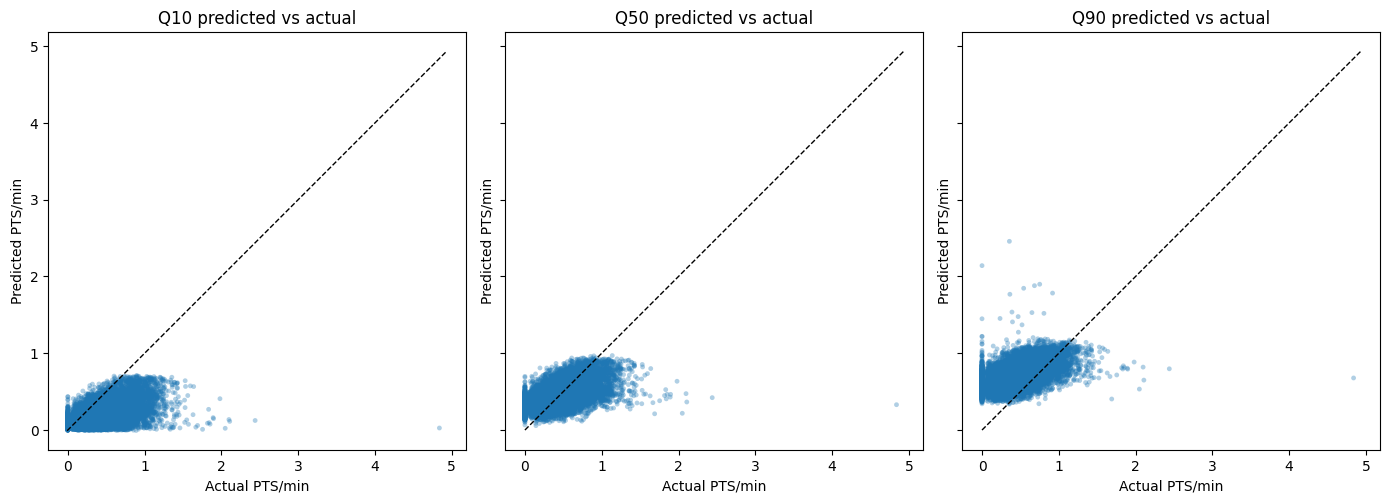

Q10 P(y ≤ pred): 0.12252547733395806
Q50 P(y ≤ pred): 0.4953730818788802
Q90 P(y ≤ pred): 0.8857326929834837
Coverage (10–90 interval): 76.32%


In [7]:
import matplotlib.pyplot as plt

y_true = y_val_ppm
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min")
    ax.set_ylabel("Predicted PTS/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

In [14]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_ppm, y_train_ppm)
upper.fit(X_train_ppm, y_train_ppm)
mid.fit(X_train_ppm, y_train_ppm)

pred_low  = lower.predict(X_val_ppm)
pred_high = upper.predict(X_val_ppm)
pred_mid  = mid.predict(X_val_ppm)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_ppm >= pred_low) & (y_val_ppm <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 78.68%


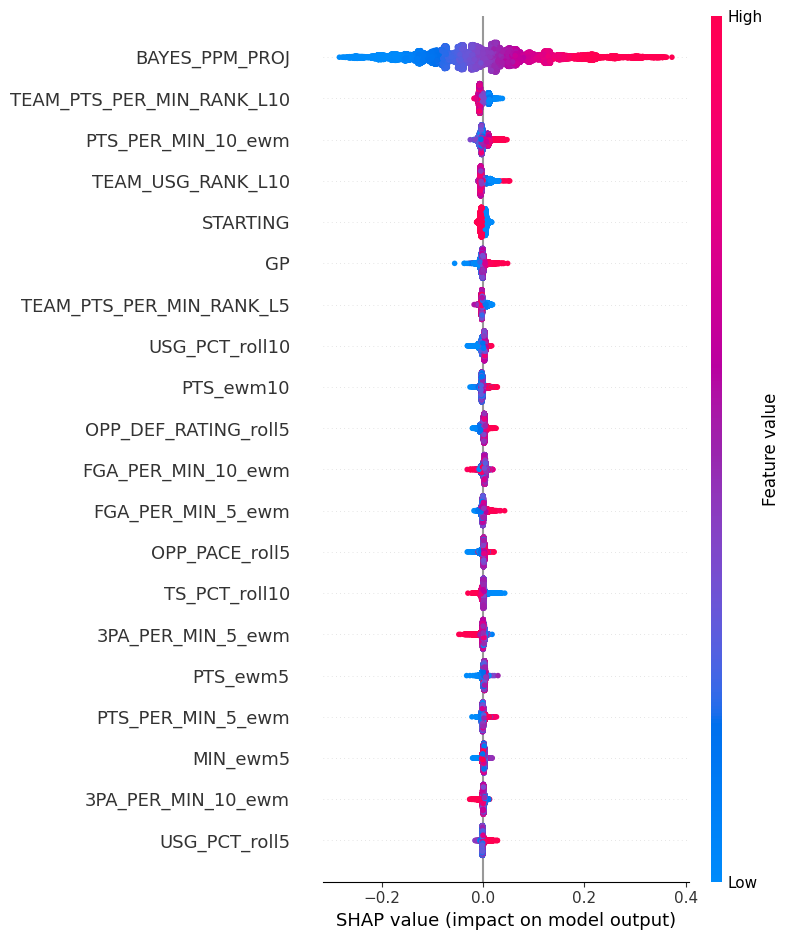

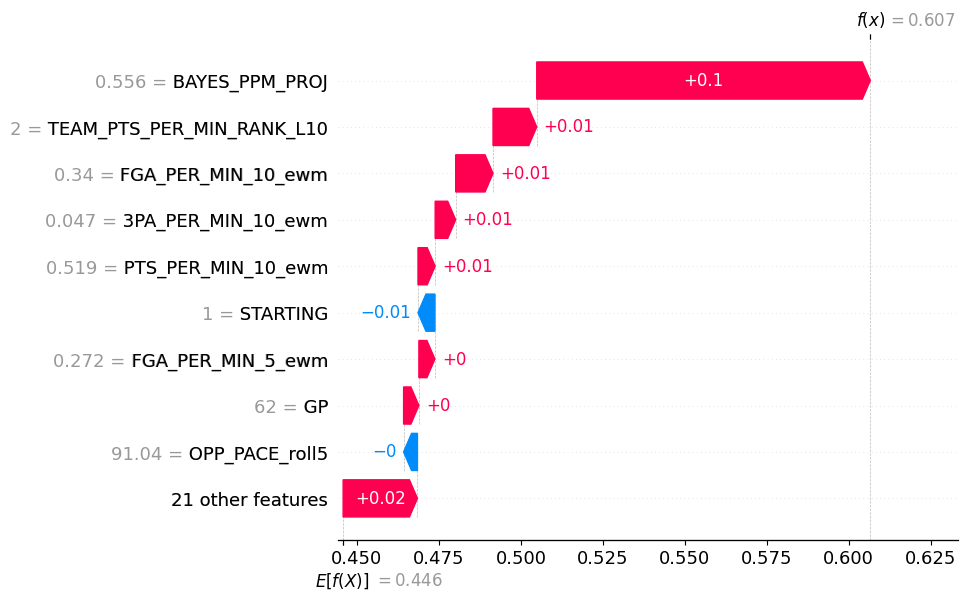

In [8]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_ppm)
shap.summary_plot(shap_values, X_val_ppm, feature_names=PPM_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [9]:
import joblib
from pathlib import Path

out_dir = Path("ppm_quantile")  # or wherever you prefer
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": PPM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, out_dir / "ppm_quantile_xgb.joblib")

['ppm_quantile/ppm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [6]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['C.J. McCollum', 'Jalen Johnson', 'Onyeka Okongwu',
       'Dyson Daniels', 'Nolan Traore', 'Ziaire Williams',
       'Jalen Brunson', 'Josh Giddey', 'Mikal Bridges',
       'Mitchell Robinson', 'Miles McBride', 'Nick Richards',
       'Landry Shamet', 'Jayson Tatum', 'Kyle Kuzma', 'Myles Turner',
       'Payton Pritchard', 'Luka Garza', 'Andre Jackson Jr',
       'Neemias Queta', 'Sam Hauser', 'Baylor Scheierman',
       'Ousmane Dieng', 'A.J. Green', 'Kevin Durant', 'Ace Bailey',
       'Tari Eason', 'Brice Sensabaugh', 'Scottie Barnes',
       'Brandon Ingram', 'R.J. Barrett', 'G.G. Jackson',
       'Sandro Mamukelashvili', 'Taylor Hendricks', 'Cedric Coward',
       'Paolo Banchero', 'Jalen Suggs', 'Klay Thompson',
       'Wendell Carter Jr', 'Zion Williamson', 'Yves Missi',
       'Derik Queen', 'Jeremiah Fears', 'Precious Achiuwa',
       'Devin Carter', 'Victor Wembanyama', 'Nikola Jokic',
       "De'Aaron Fox", 'Jamal Murray', 'Devin Vassell', 'Aaron Gordon',
       'Dyl

In [7]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

ppm_bundle = joblib.load("src/models/saved_models/ppm_quantile_xgb.joblib")
ppm_quantile_models = ppm_bundle["quantile_models"]
ppm_feature_names = ppm_bundle["feature_names"]

In [8]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] Andre Jackson Jr: min_pipeline returned None (need >= 10 games)
[SKIP] A.J. Green: min_pipeline returned None (need >= 10 games)
[SKIP] R.J. Barrett: min_pipeline returned None (need >= 10 games)
[SKIP] G.G. Jackson: min_pipeline returned None (need >= 10 games)
[SKIP] Wendell Carter Jr: min_pipeline returned None (need >= 10 games)
[SKIP] Devin Carter: min_pipeline returned None (need >= 10 games)


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,CJ McCollum,28.503300,34.207275,37.908482,0.221759,0.591460,0.958904,6.320861,20.232218,36.350598,30.029737
1,Jalen Johnson,24.980799,32.115597,37.335098,0.155657,0.513589,0.834584,3.888427,16.494214,31.159291,27.270864
2,Onyeka Okongwu,21.597481,29.285728,35.174381,0.213865,0.429393,0.722815,4.618936,12.575095,25.424563,20.805627
3,Dyson Daniels,23.023590,30.818968,36.269760,0.116426,0.296819,0.546110,2.680550,9.147664,19.807291,17.126741
4,Nolan Traore,17.614111,25.539858,32.826130,0.171473,0.389821,0.946384,3.020341,9.955969,31.066136,28.045795


In [14]:

# ---------------------------------------------------------
# 1. THE POINTS SIMULATION ENGINE (CONTINUOUS TRIANGULAR)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.85, hi_scale=1.15, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates continuous samples for Points Per Minute or Minutes.
    Uses your specified scales (0.85/1.15) to maintain the existing distribution.
    """
    mode = float(row[q50])
    left = min(float(row[q10]) * lo_scale, mode - 0.0001)
    right = max(float(row[q90]) * hi_scale, mode + 0.0001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_pts_simulation(row, n_sims=10_000):
    """
    Paired Simulation: Minutes * PPM.
    Maintains continuous distribution for scoring.
    """
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.85, hi_scale=1.15, low=0, high=48, n_sims=n_sims,
    )
    
    sim_ppm = triangular_clip(
        row,
        "PRED_PPM_Q10", "PRED_PPM_Q50", "PRED_PPM_Q90",
        lo_scale=0.85, hi_scale=1.15, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Return the continuous point totals
    return sim_min * sim_ppm

# ---------------------------------------------------------
# 2. CALCULATION & FORMATTING LOOP
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# Ensure line_by_name uses the same lookup logic as your other models
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, 
        })
        continue

    # Generate the simulated point outcomes
    pts_sims = run_pts_simulation(row)
    line = float(line)
    p_over = float(np.mean(pts_sims > line))
    p_under = float(np.mean(pts_sims < line))
    p_push = float(np.mean(pts_sims == line)) 

    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_PTS_Q50": round(row["PRED_PTS_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "EDGE": round(row["PRED_PTS_Q50"] - line, 2),
    })

line_probs_df = pd.DataFrame(results)
line_probs_df.sort_values(by="EDGE", ascending=False).head()

,PLAYER_NAME,LINE,PRED_MIN_Q50,PRED_PTS_Q50,P_OVER,P_UNDER,EDGE
47,De'Aaron Fox,15.5,30.34,21.59,0.841,0.159,6.09
53,Keldon Johnson,12.5,28.70,18.33,0.794,0.206,5.83
37,Klay Thompson,9.5,26.22,15.15,0.837,0.163,5.65
49,Devin Vassell,12.5,31.72,17.54,0.765,0.235,5.04
15,Myles Turner,11.5,28.60,16.35,0.801,0.199,4.85
